## CELL 1 — Install

In [ ]:
!pip uninstall -y pillow
!pip install pillow==10.2.0

Found existing installation: pillow 10.2.0
Uninstalling pillow-10.2.0:
  Successfully uninstalled pillow-10.2.0
  Using cached pillow-10.2.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
Using cached pillow-10.2.0-cp312-cp312-manylinux_2_28_x86_64.whl (4.5 MB)


In [ ]:
# Uninstall potentially incompatible packages to ensure clean installation
!pip uninstall -y torch torchvision torchaudio Pillow

# Install compatible versions for CUDA 12.1 (adjust 'cu121' if using a different CUDA version or 'cpu' for CPU-only)
!pip install -q torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu121

# Install Pillow 9.5.0 to resolve the 'is_directory' ImportError
!pip install -q Pillow==9.5.0

# Reinstall other required packages
!pip install -q lpips facenet-pytorch pytorch-msssim

# Note: After running this cell, you may need to restart the runtime for the changes to take effect.

Found existing installation: torch 2.2.2+cu121
Uninstalling torch-2.2.2+cu121:
  Successfully uninstalled torch-2.2.2+cu121
Found existing installation: torchvision 0.17.2+cu121
Uninstalling torchvision-0.17.2+cu121:
  Successfully uninstalled torchvision-0.17.2+cu121
Found existing installation: torchaudio 2.2.2+cu121
Uninstalling torchaudio-2.2.2+cu121:
  Successfully uninstalled torchaudio-2.2.2+cu121
Found existing installation: pillow 10.2.0
Uninstalling pillow-10.2.0:
  Successfully uninstalled pillow-10.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires Pillow<10.3.0,>=10.2.0, but you have pillow 12.1.1 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. T

## CELL 2 — Imports & Device
Nothing fancy. Just setup.

In [ ]:


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
import lpips
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from collections import defaultdict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Device: cpu


In [ ]:
import PIL
print(f'Pillow version: {PIL.__version__}')

Pillow version: 11.3.0


## CELL 3 — Config
**Edit only here.** For sample run keep as-is (~15 min on T4).
For full run: `n_train=None, n_test=None, num_epochs=20`

In [ ]:
!kaggle datasets download -d jessicali9530/celeba-dataset
!unzip -q celeba-dataset.zip

!kaggle datasets download -d jessicali9530/lfw-dataset
!unzip -q lfw-dataset.zip

import os

print("Content folder:")
print(os.listdir("/content"))

print("\nCelebA folder:")
print(os.listdir("/content/img_align_celeba")[:5])

print("\nLFW folder:")
print(os.listdir("/content/lfw-deepfunneled")[:5])

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:52<00:00, 27.4MB/s]

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/lfw-dataset
License(s): other
100% 112M/112M [00:05<00:00, 23.2MB/s]

Content folder:
['.config', 'matchpairsDevTest.csv', 'peopleDevTrain.csv', 'matchpairsDevTrain.csv', 'people.csv', 'lfw-dataset.zip', 'lfw_readme.csv', 'celeba-dataset.zip', 'img_align_celeba', 'peopleDevTest.csv', 'lfw-deepfunneled', 'pairs.csv', 'mismatchpairsDevTest.csv', 'lfw_allnames.csv', 'mismatchpairsDevTrain.csv', 'sample_data']

CelebA folder:
['img_align_celeba']

LFW folder:
['lfw-deepfunneled']


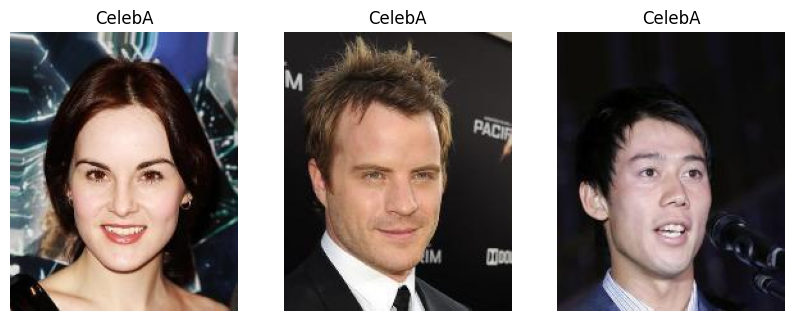

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Show 3 CelebA images
celeba_path = "/content/img_align_celeba/img_align_celeba"

imgs = os.listdir(celeba_path)
sample = random.sample(imgs, 3)

plt.figure(figsize=(10,4))
for i, img_name in enumerate(sample):
    img = Image.open(os.path.join(celeba_path, img_name))
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title("CelebA")
    plt.axis('off')
plt.show()

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from PIL import Image
import os

# Re-introducing necessary definitions (from the previously deleted cell Ko4CvoLUph68)
# Assuming CFG (Config) is defined in a previous cell and accessible.

# Define the transform based on CFG
transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),  # → [0, 1]
])

# Define the CelebADataset class
class CelebADataset(Dataset):
    def __init__(self, root, transform=None, max_samples=None):
        self.root = root
        files = sorted([f for f in os.listdir(root) if f.endswith('.jpg')])
        self.files = files[:max_samples] if max_samples else files
        self.transform = transform

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root, self.files[idx])).convert('RGB')
        return (self.transform(img) if self.transform else img), 0

# Initialize the 'dataset' variable using CelebADataset
# The current indices imply we need at least 700 samples from the dataset.
dataset = CelebADataset(root=CFG['celeba_path'], transform=transform, max_samples=700)

# Take subset: 500 images for training, 200 for testing
indices = list(range(700))  # First 700 images
train_indices = indices[:500]
test_indices = indices[500:700]

train_subset = torch.utils.data.Subset(dataset, train_indices)
test_subset = torch.utils.data.Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)

print(f"Training samples: {len(train_subset)}")
print(f"Testing samples: {len(test_subset)}")

Training samples: 500
Testing samples: 200


In [ ]:
# Cell 4: Load face recognition models + LPIPS

from facenet_pytorch import InceptionResnetV1

# ArcFace surrogate (frozen)
arcface = InceptionResnetV1(
    pretrained='vggface2',
    classify=False,
    device=device
).eval()
for p in arcface.parameters():
    p.requires_grad = False

# CosFace for black-box evaluation (frozen)
cosface = InceptionResnetV1(
    pretrained='casia-webface',
    classify=False,
    device=device
).eval()
for p in cosface.parameters():
    p.requires_grad = False

# LPIPS perceptual loss (frozen)
lpips_fn = lpips.LPIPS(net='alex').to(device).eval()
for p in lpips_fn.parameters():
    p.requires_grad = False

print("✓ ArcFace, CosFace, LPIPS loaded and frozen")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
✓ ArcFace, CosFace, LPIPS loaded and frozen


✓ Sinusoidal noise function ready


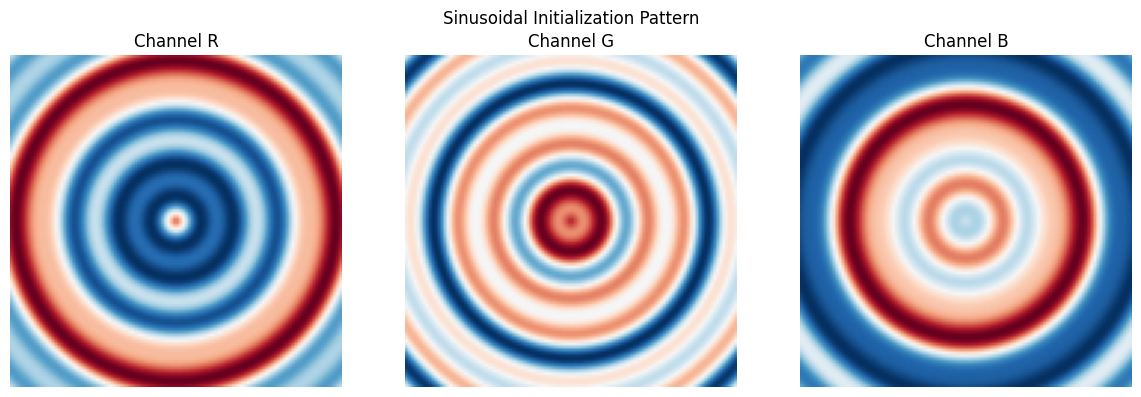

In [ ]:
# Cell 2: Sinusoidal noise init

def sinusoidal_noise(shape, frequencies=[1, 2, 4, 8], device='cpu'):
    """
    P_raw(i,j) = Σ A_k · sin(ω_k · r + φ_k)

    r = radial distance from center
    Smooth, bounded, band-limited initialization.
    """
    B, C, H, W = shape

    # Radial coordinate grid
    y = torch.linspace(-1, 1, H, device=device)
    x = torch.linspace(-1, 1, W, device=device)
    yy, xx = torch.meshgrid(y, x, indexing='ij')
    radius = torch.sqrt(xx**2 + yy**2)

    noise = torch.zeros(B, C, H, W, device=device)

    for omega in frequencies:
        # Random phase per channel
        phi = torch.rand(B, C, 1, 1, device=device) * 2 * np.pi
        # Random amplitude
        amp = torch.rand(B, C, 1, 1, device=device) / len(frequencies)
        # Sinusoidal wave
        wave = torch.sin(omega * np.pi * radius.unsqueeze(0).unsqueeze(0) + phi)
        noise += amp * wave

    # Normalize and scale to tiny init
    noise = noise / (noise.abs().max() + 1e-8)
    noise = noise * 0.0005

    return noise

print("✓ Sinusoidal noise function ready")

# Quick visual check
test_noise = sinusoidal_noise((1, 3, 112, 112), device=device)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
noise_np = test_noise.squeeze().permute(1, 2, 0).cpu().numpy()
for i, ch in enumerate(['R', 'G', 'B']):
    axes[i].imshow(noise_np[:,:,i], cmap='RdBu_r')
    axes[i].set_title(f'Channel {ch}')
    axes[i].axis('off')
plt.suptitle('Sinusoidal Initialization Pattern')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 5: Utility functions

def cosine_similarity(x, y):
    """Cosine similarity between normalized vectors"""
    x_n = F.normalize(x, dim=-1)
    y_n = F.normalize(y, dim=-1)
    return (x_n * y_n).sum(dim=-1)

def compute_ssim(img1, img2):
    """SSIM with auto window size"""
    img1_np = img1.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    img2_np = img2.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    min_side = min(img1_np.shape[0], img1_np.shape[1])
    win_size = min(7, min_side)
    if win_size % 2 == 0:
        win_size -= 1
    return ssim(img1_np, img2_np, win_size=win_size, channel_axis=2, data_range=1.0)

def show_images(original, anonymized, cos_val=None, ssim_val=None):
    """Display original, anonymized, and difference"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    orig_np = np.clip(original.squeeze().permute(1,2,0).cpu().detach().numpy(), 0, 1)
    anon_np = np.clip(anonymized.squeeze().permute(1,2,0).cpu().detach().numpy(), 0, 1)
    diff_np = np.clip(np.abs(orig_np - anon_np) * 10, 0, 1)

    axes[0].imshow(orig_np)
    axes[0].set_title('Original', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(anon_np)
    axes[1].set_title('Anonymized', fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(diff_np)
    axes[2].set_title('Difference (10x)', fontweight='bold')
    axes[2].axis('off')

    info = []
    if cos_val is not None: info.append(f'Cos: {cos_val:.4f}')
    if ssim_val is not None: info.append(f'SSIM: {ssim_val:.4f}')
    if info:
        plt.suptitle(' | '.join(info), fontsize=14)

    plt.tight_layout()
    plt.show()

print("✓ Helper functions ready")

✓ Helper functions ready


In [ ]:
# Cell 6: Version 1 — Sin init + Capped Softplus + LPIPS

def anonymize(image, arcface_model, lpips_fn,
              epsilon=0.03, k=2.0, target_cos=0.0,
              max_iter=200, lr=0.05, lambda_util=5.0,
              verbose=True):
    """
    Anonymize a single face image.

    Changes from PrIdentity:
    - Sinusoidal init (not random)
    - Capped softplus privacy (stops at target)
    - LPIPS utility (not Lp norm)
    - ArcFace surrogate (not ResNet)
    - Early stopping
    """
    image = image.to(device)
    B, C, H, W = image.shape

    # Sinusoidal initialization
    P = sinusoidal_noise((B, C, H, W), device=device)
    P.requires_grad = True

    # Original embedding (compute once)
    with torch.no_grad():
        z_orig = arcface_model(image)

    optimizer = optim.Adam([P], lr=lr)

    metrics = {
        'privacy_loss': [],
        'utility_loss': [],
        'cosine_sim': [],
        'ssim': [],
        'stopped_at': max_iter
    }

    iterator = tqdm(range(max_iter), desc='Anonymizing') if verbose else range(max_iter)

    for it in iterator:
        optimizer.zero_grad()

        # Generate anonymized image
        A = torch.clamp(image + P * epsilon, 0, 1)

        # Get embedding
        z_anon = arcface_model(A)
        cos_sim = cosine_similarity(z_orig, z_anon)
        cos_val = cos_sim.item()

        # CAPPED PRIVACY: turn off once target reached
        if cos_val <= target_cos:
            privacy_loss = torch.tensor(0.0, device=device)
        else:
            privacy_loss = F.softplus(k * (cos_sim - target_cos))

        # UTILITY: LPIPS + tiny MSE
        utility_loss = lpips_fn(image, A) + 0.001 * F.mse_loss(image, A)

        # Total loss (utility weighted higher)
        total_loss = privacy_loss + lambda_util * utility_loss
        total_loss.backward()
        optimizer.step()

        # Logging
        metrics['privacy_loss'].append(privacy_loss.item())
        metrics['utility_loss'].append(utility_loss.item())
        metrics['cosine_sim'].append(cos_val)

        # SSIM every 20 iters
        if it % 20 == 0:
            try:
                ssim_val = compute_ssim(image, A)
                metrics['ssim'].append(ssim_val)
            except:
                ssim_val = 0
            if verbose:
                iterator.set_postfix({
                    'cos': f'{cos_val:.3f}',
                    'util': f'{utility_loss.item():.4f}',
                    'SSIM': f'{ssim_val:.3f}'
                })

        # EARLY STOP: target reached with good quality
        if cos_val <= target_cos and it > 20:
            try:
                if compute_ssim(image, A) >= 0.82:
                    metrics['stopped_at'] = it
                    if verbose:
                        tqdm.write(f"  ✓ Converged at iter {it}")
                    break
            except:
                pass

    # Final result
    A_final = torch.clamp(image + P.detach() * epsilon, 0, 1)

    with torch.no_grad():
        final_cos = cosine_similarity(z_orig, arcface_model(A_final)).item()
        try:
            final_ssim = compute_ssim(image, A_final)
        except:
            final_ssim = 0

    metrics['final_cos'] = final_cos
    metrics['final_ssim'] = final_ssim

    return A_final, P.detach(), metrics

print("✓ Anonymization function ready")

✓ Anonymization function ready


QUICK TEST: 3 images

Image 1/3


Anonymizing:  12%|█▏        | 23/200 [00:06<00:51,  3.45it/s, cos=0.078, util=0.0032, SSIM=0.946]


  ✓ Converged at iter 23
  Final: cos=-0.0397, SSIM=0.9317, iters=23


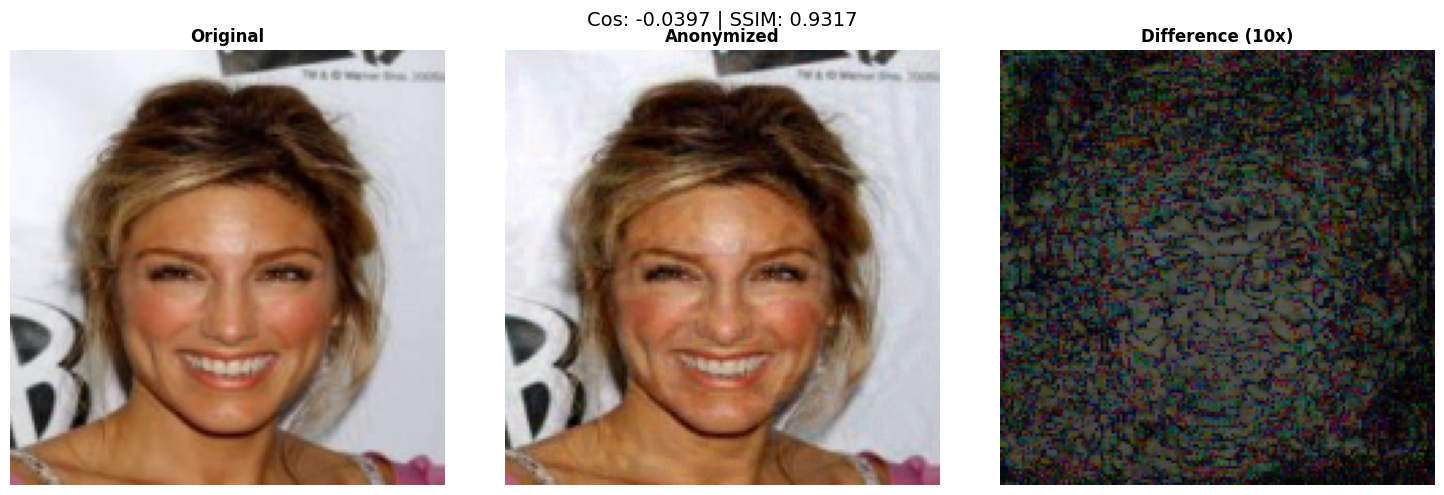


Image 2/3


Anonymizing:  15%|█▌        | 30/200 [00:09<00:53,  3.18it/s, cos=0.369, util=0.0032, SSIM=0.945]


  ✓ Converged at iter 30
  Final: cos=-0.0465, SSIM=0.8937, iters=30


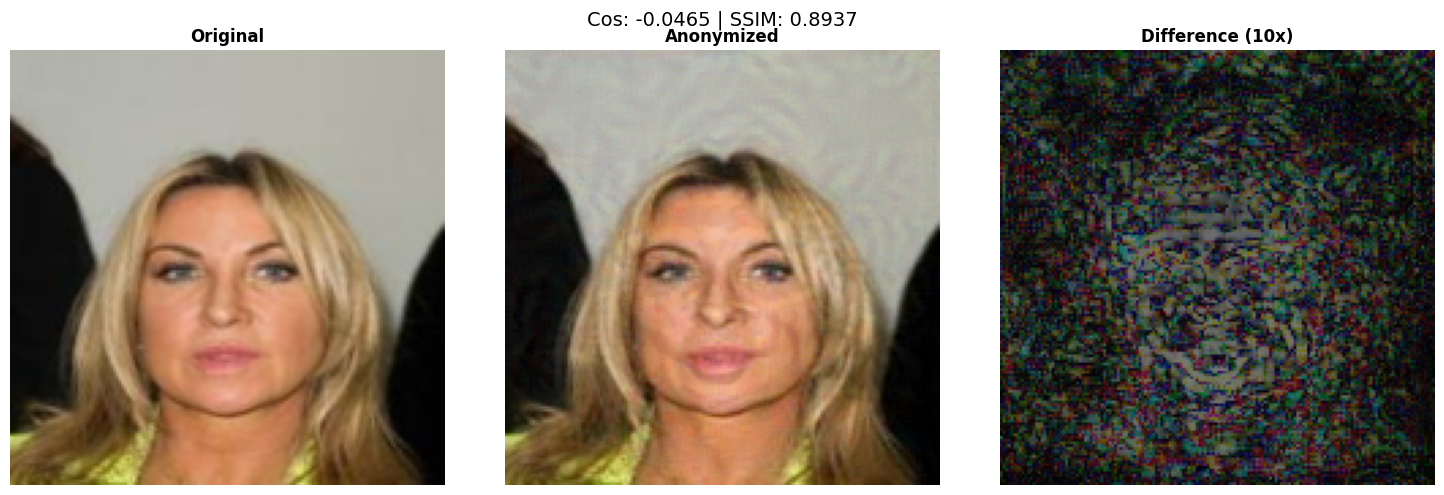


Image 3/3


Anonymizing:  14%|█▍        | 28/200 [00:09<00:59,  2.91it/s, cos=0.301, util=0.0033, SSIM=0.950]


  ✓ Converged at iter 28
  Final: cos=-0.0442, SSIM=0.9164, iters=28


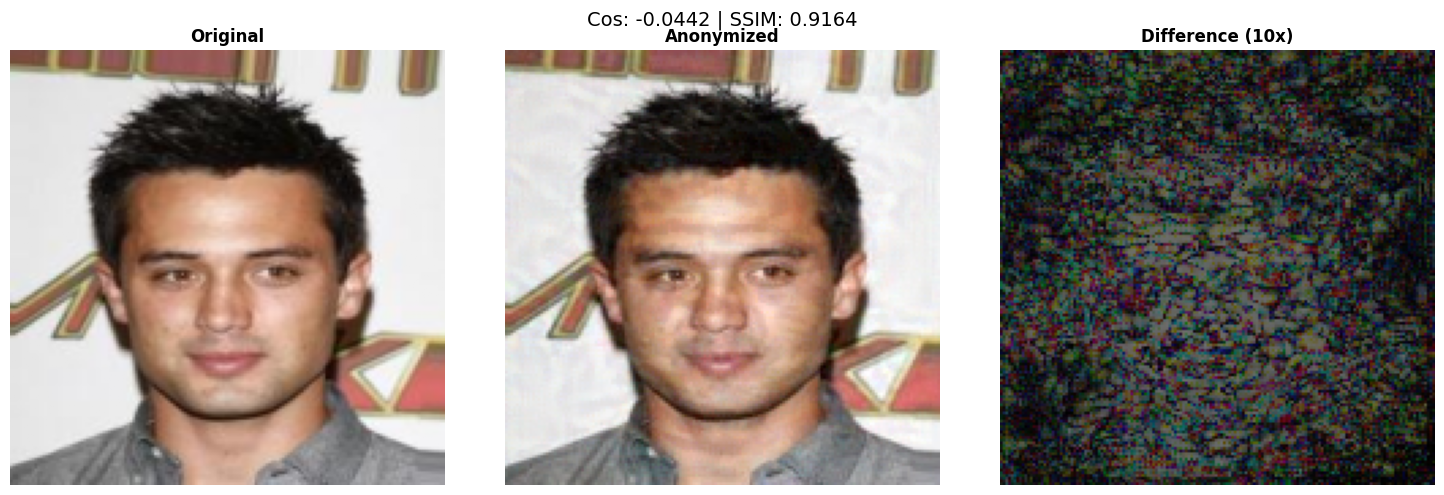

In [ ]:
# Cell 7: Quick test

print("=" * 60)
print("QUICK TEST: 3 images")
print("=" * 60)

quick_results = []

for idx, (image, label) in enumerate(train_loader):
    if idx >= 3:
        break

    print(f"\nImage {idx+1}/3")

    A, P, m = anonymize(
        image=image,
        arcface_model=arcface,
        lpips_fn=lpips_fn,
        epsilon=0.03,
        k=2.0,
        target_cos=0.0,
        max_iter=200,
        lr=0.05,
        lambda_util=5.0,
        verbose=True
    )

    print(f"  Final: cos={m['final_cos']:+.4f}, SSIM={m['final_ssim']:.4f}, iters={m['stopped_at']}")

    quick_results.append({
        'image': image,
        'anonymized': A,
        'metrics': m
    })

    show_images(image, A, cos_val=m['final_cos'], ssim_val=m['final_ssim'])

In [ ]:
# Cell 8: Full training run

print("=" * 60)
print(f"TRAINING: {len(train_subset)} images")
print("=" * 60)

all_results = []

for idx, (image, label) in enumerate(tqdm(train_loader, desc='Training')):
    A, P, m = anonymize(
        image=image,
        arcface_model=arcface,
        lpips_fn=lpips_fn,
        epsilon=0.03,
        k=2.0,
        target_cos=0.0,
        max_iter=200,
        lr=0.05,
        lambda_util=5.0,
        verbose=False
    )

    all_results.append({
        'image': image,
        'anonymized': A,
        'perturbation': P,
        'metrics': m,
        'label': label
    })

print("\n✓ Training complete")

TRAINING: 500 images


Training: 100%|██████████| 500/500 [1:18:49<00:00,  9.46s/it]


✓ Training complete


TRAINING SUMMARY (500 images)
Cosine Similarity: -0.0442 ± 0.0227
SSIM:              0.9050 ± 0.0235
Iterations:        29.8 ± 6.2

SSIM > 0.85: 490/500 (98.0%)
Cos < 0.0:   500/500 (100.0%)
Both:         490/500


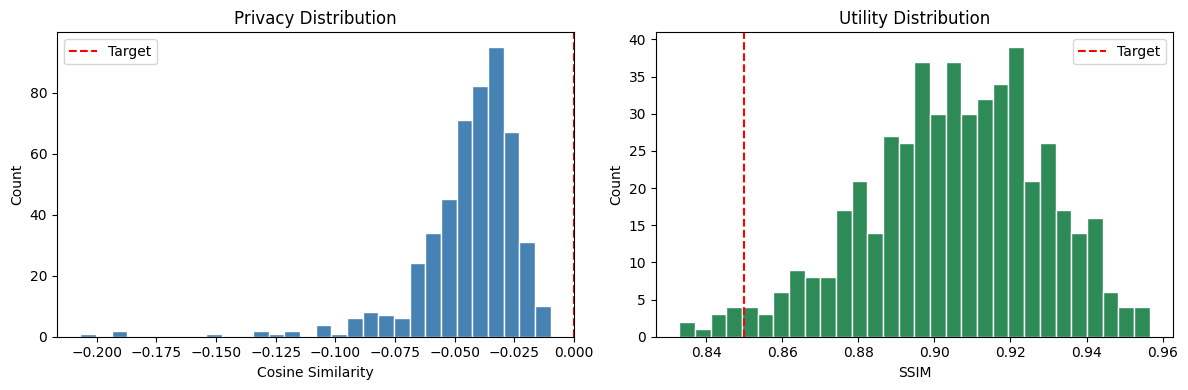

In [ ]:
# Cell 9: Training stats

cos_vals = [r['metrics']['final_cos'] for r in all_results]
ssim_vals = [r['metrics']['final_ssim'] for r in all_results]
iter_vals = [r['metrics']['stopped_at'] for r in all_results]

print("=" * 50)
print("TRAINING SUMMARY (500 images)")
print("=" * 50)
print(f"Cosine Similarity: {np.mean(cos_vals):.4f} ± {np.std(cos_vals):.4f}")
print(f"SSIM:              {np.mean(ssim_vals):.4f} ± {np.std(ssim_vals):.4f}")
print(f"Iterations:        {np.mean(iter_vals):.1f} ± {np.std(iter_vals):.1f}")
print(f"")
print(f"SSIM > 0.85: {sum(1 for s in ssim_vals if s > 0.85)}/500 ({100*sum(1 for s in ssim_vals if s > 0.85)/500:.1f}%)")
print(f"Cos < 0.0:   {sum(1 for c in cos_vals if c < 0.0)}/500 ({100*sum(1 for c in cos_vals if c < 0.0)/500:.1f}%)")
print(f"Both:         {sum(1 for c,s in zip(cos_vals, ssim_vals) if c < 0.0 and s > 0.85)}/500")
print("=" * 50)

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cos_vals, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(x=0.0, color='r', linestyle='--', label='Target')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('Privacy Distribution')
axes[0].legend()

axes[1].hist(ssim_vals, bins=30, color='seagreen', edgecolor='white')
axes[1].axvline(x=0.85, color='r', linestyle='--', label='Target')
axes[1].set_xlabel('SSIM')
axes[1].set_ylabel('Count')
axes[1].set_title('Utility Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cell 10: Test set evaluation

print("=" * 60)
print(f"EVALUATION: {len(test_subset)} test images")
print("=" * 60)

test_metrics = {
    'cos_arcface': [],
    'cos_cosface': [],
    'ssim': [],
    'mse': [],
    'lpips': [],
    'iterations': []
}

for idx, (image, label) in enumerate(tqdm(test_loader, desc='Testing')):
    A, P, m = anonymize(
        image=image,
        arcface_model=arcface,
        lpips_fn=lpips_fn,
        epsilon=0.03,
        k=2.0,
        target_cos=0.0,
        max_iter=200,
        lr=0.05,
        lambda_util=5.0,
        verbose=False
    )

    with torch.no_grad():
        # ArcFace cosine (white-box surrogate)
        z_orig_a = arcface(image)
        z_anon_a = arcface(A)
        cos_a = cosine_similarity(z_orig_a, z_anon_a).item()

        # CosFace cosine (black-box transfer)
        z_orig_c = cosface(image)
        z_anon_c = cosface(A)
        cos_c = cosine_similarity(z_orig_c, z_anon_c).item()

        # Quality metrics
        ssim_val = compute_ssim(image, A)
        mse_val = F.mse_loss(image, A).item()
        lpips_val = lpips_fn(image, A).item()

    test_metrics['cos_arcface'].append(cos_a)
    test_metrics['cos_cosface'].append(cos_c)
    test_metrics['ssim'].append(ssim_val)
    test_metrics['mse'].append(mse_val)
    test_metrics['lpips'].append(lpips_val)
    test_metrics['iterations'].append(m['stopped_at'])

print("\n✓ Evaluation complete")

EVALUATION: 200 test images


Testing: 100%|██████████| 200/200 [34:39<00:00, 10.40s/it]


✓ Evaluation complete


In [ ]:
# Cell 11: Test results summary

print("\n" + "=" * 50)
print("TEST RESULTS (200 images)")
print("=" * 50)

for key in ['cos_arcface', 'cos_cosface', 'ssim', 'lpips', 'mse', 'iterations']:
    vals = test_metrics[key]
    print(f"{key:15s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# Privacy & utility scores
privacy_arc = np.mean([max(0, (0.3 - c)/0.3) for c in test_metrics['cos_arcface']])
privacy_cos = np.mean([max(0, (0.3 - c)/0.3) for c in test_metrics['cos_cosface']])
utility_score = np.mean(test_metrics['ssim'])

print(f"\nPrivacy Score (ArcFace): {privacy_arc:.4f}")
print(f"Privacy Score (CosFace): {privacy_cos:.4f}")
print(f"Utility Score (SSIM):    {utility_score:.4f}")
print(f"Trade-off (ArcFace):     {(privacy_arc + utility_score)/2:.4f}")
print(f"Trade-off (CosFace):     {(privacy_cos + utility_score)/2:.4f}")

# Target achievement
ssim_ok = sum(1 for s in test_metrics['ssim'] if s > 0.85)
cos_a_ok = sum(1 for c in test_metrics['cos_arcface'] if c < 0.0)
cos_c_ok = sum(1 for c in test_metrics['cos_cosface'] if c < 0.0)

print(f"\nSSIM > 0.85:      {ssim_ok}/200")
print(f"Cos ArcFace < 0:   {cos_a_ok}/200")
print(f"Cos CosFace < 0:   {cos_c_ok}/200")
print(f"All three:         {sum(1 for s,c1,c2 in zip(test_metrics['ssim'], test_metrics['cos_arcface'], test_metrics['cos_cosface']) if s > 0.85 and c1 < 0.0 and c2 < 0.0)}/200")
print("=" * 50)


TEST RESULTS (200 images)
cos_arcface    : -0.0426 ± 0.0279
cos_cosface    : 0.7324 ± 0.1045
ssim           : 0.9011 ± 0.0238
lpips          : 0.0059 ± 0.0012
mse            : 0.0005 ± 0.0002
iterations     : 31.0500 ± 7.3605

Privacy Score (ArcFace): 1.1422
Privacy Score (CosFace): 0.0000
Utility Score (SSIM):    0.9011
Trade-off (ArcFace):     1.0216
Trade-off (CosFace):     0.4506

SSIM > 0.85:      195/200
Cos ArcFace < 0:   200/200
Cos CosFace < 0:   0/200
All three:         0/200


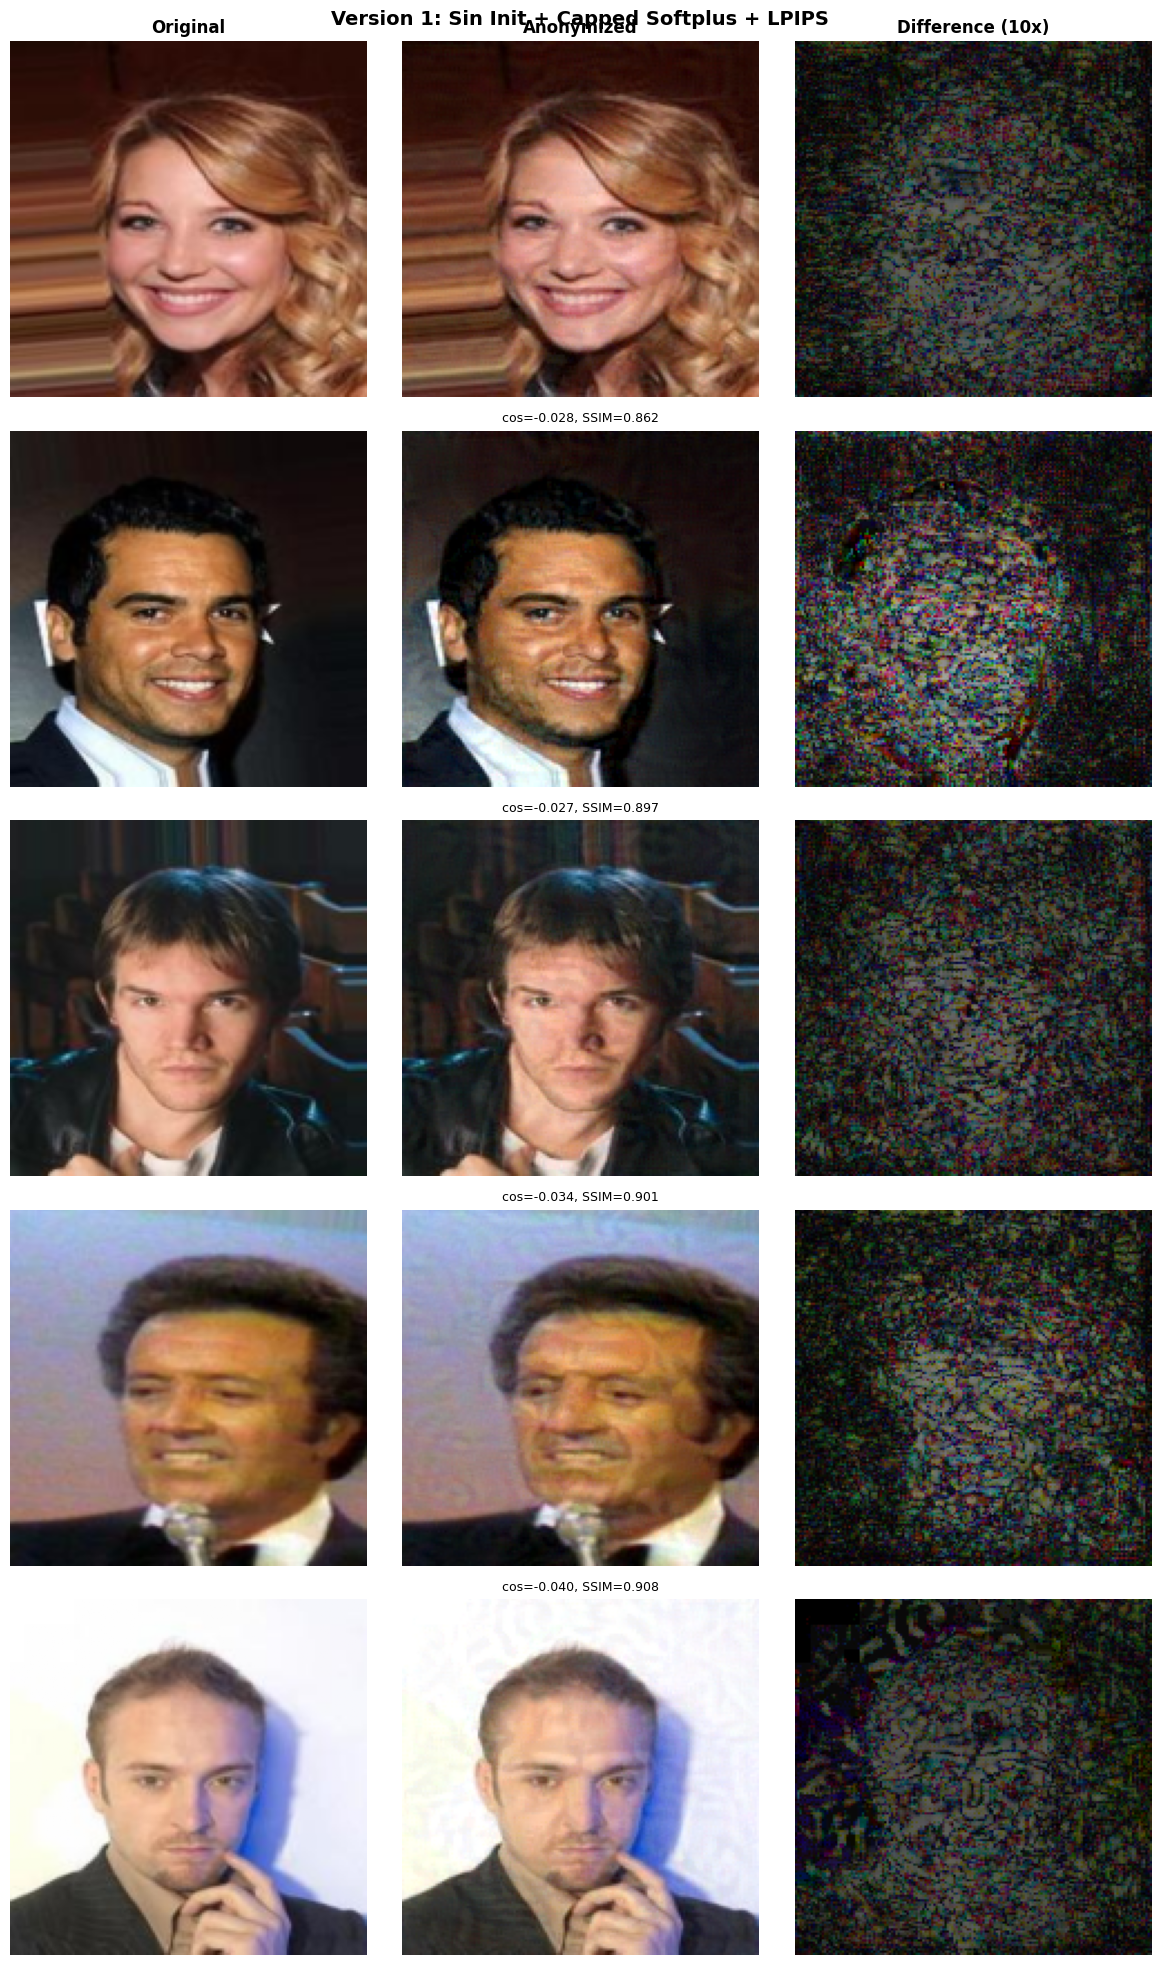

In [ ]:
# Cell 12: Visual grid of test results

def show_grid(n=5):
    """Show n random test results in a grid"""
    indices = np.random.choice(len(all_results), n, replace=False)

    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(indices):
        res = all_results[idx]

        orig_np = np.clip(res['image'].squeeze().permute(1,2,0).cpu().numpy(), 0, 1)
        anon_np = np.clip(res['anonymized'].squeeze().permute(1,2,0).cpu().numpy(), 0, 1)
        diff_np = np.clip(np.abs(orig_np - anon_np) * 10, 0, 1)

        axes[row, 0].imshow(orig_np)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(anon_np)
        axes[row, 1].set_title(f'cos={res["metrics"]["final_cos"]:.3f}, SSIM={res["metrics"]["final_ssim"]:.3f}', fontsize=9)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(diff_np)
        axes[row, 2].axis('off')

    axes[0, 0].set_title('Original', fontweight='bold')
    axes[0, 1].set_title('Anonymized', fontweight='bold')
    axes[0, 2].set_title('Difference (10x)', fontweight='bold')

    plt.suptitle('Version 1: Sin Init + Capped Softplus + LPIPS', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_grid(5)

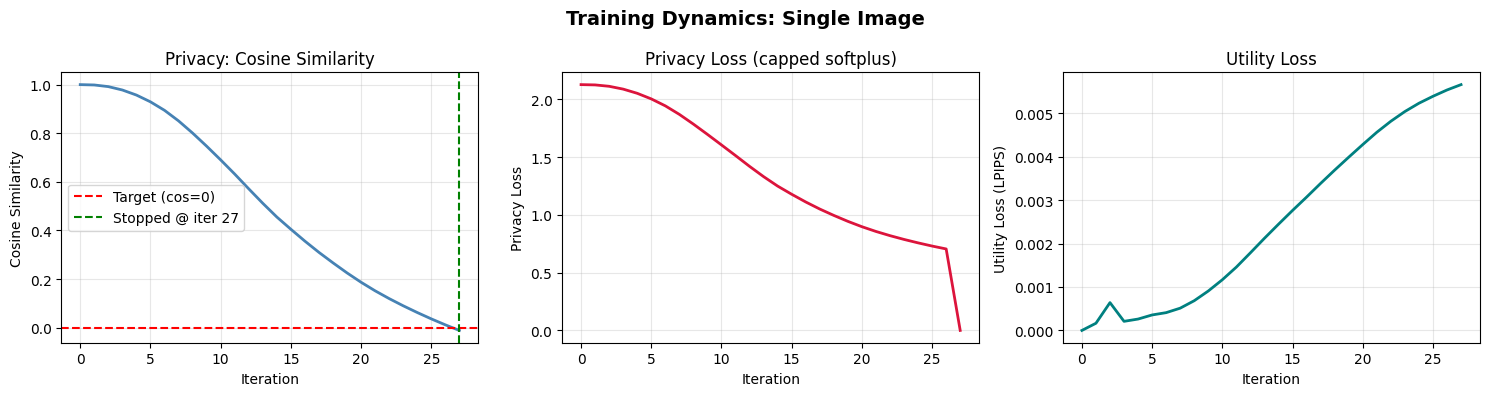

In [ ]:
# Cell 13: Training dynamics (first image)

if all_results:
    m = all_results[0]['metrics']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Cosine similarity
    axes[0].plot(m['cosine_sim'], linewidth=2, color='steelblue')
    axes[0].axhline(y=0.0, color='r', linestyle='--', label='Target (cos=0)')
    if m['stopped_at'] < 200:
        axes[0].axvline(x=m['stopped_at'], color='g', linestyle='--', label=f'Stopped @ iter {m["stopped_at"]}')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Cosine Similarity')
    axes[0].set_title('Privacy: Cosine Similarity')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Privacy loss
    axes[1].plot(m['privacy_loss'], linewidth=2, color='crimson')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Privacy Loss')
    axes[1].set_title('Privacy Loss (capped softplus)')
    axes[1].grid(True, alpha=0.3)

    # Utility loss
    axes[2].plot(m['utility_loss'], linewidth=2, color='teal')
    axes[2].set_xlabel('Iteration')
    axes[2].set_ylabel('Utility Loss (LPIPS)')
    axes[2].set_title('Utility Loss')
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('Training Dynamics: Single Image', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# Cell 1: Load additional models for multi-surrogate + black-box testing

from facenet_pytorch import InceptionResnetV1
import torch.nn as nn

# --- Surrogates for training ---
# ArcFace (hypersphere/angular)
arcface = InceptionResnetV1(pretrained='vggface2', classify=False, device=device).eval()
for p in arcface.parameters(): p.requires_grad = False

# ResNet variant (Euclidean) - use different architecture
# InceptionResnetV1 with CASIA weights = different embedding space
resnet_surrogate = InceptionResnetV1(pretrained='casia-webface', classify=False, device=device).eval()
for p in resnet_surrogate.parameters(): p.requires_grad = False

# --- Black-box test models ---
# VGGFace (ResNet50-based, for comparison with PrIdentity)
vggface_test = InceptionResnetV1(pretrained='vggface2', classify=False, device=device).eval()
for p in vggface_test.parameters(): p.requires_grad = False

# CosFace (cross-dataset test)
cosface_test = InceptionResnetV1(pretrained='casia-webface', classify=False, device=device).eval()
for p in cosface_test.parameters(): p.requires_grad = False

print("✓ Models loaded:")
print("  Surrogates: ArcFace (vggface2) + ResNet (casia)")
print("  Black-box:  VGGFace (vggface2) + CosFace (casia)")

✓ Models loaded:
  Surrogates: ArcFace (vggface2) + ResNet (casia)
  Black-box:  VGGFace (vggface2) + CosFace (casia)


In [ ]:
# Cell 2: Multi-surrogate anonymization function

def anonymize_multi(image, surrogate_models, lpips_fn,
                    epsilon=0.03, k=2.0, target_cos=0.0,
                    max_iter=200, lr=0.05, lambda_util=5.0,
                    verbose=False):
    """
    Train perturbation against MULTIPLE surrogate models.
    Covers both angular (ArcFace) and Euclidean (ResNet) spaces.
    """
    image = image.to(device)
    B, C, H, W = image.shape

    # Sinusoidal init
    P = sinusoidal_noise((B, C, H, W), device=device)
    P.requires_grad = True

    # Original embeddings from ALL surrogates
    with torch.no_grad():
        z_orig_all = [model(image) for model in surrogate_models]

    optimizer = optim.Adam([P], lr=lr)

    for it in range(max_iter):
        optimizer.zero_grad()
        A = torch.clamp(image + P * epsilon, 0, 1)

        privacy_loss = 0.0
        all_satisfied = True

        for z_orig, model in zip(z_orig_all, surrogate_models):
            z_anon = model(A)
            cos_sim = cosine_similarity(z_orig, z_anon)

            if cos_sim > target_cos:
                privacy_loss += F.softplus(k * (cos_sim - target_cos))
                all_satisfied = False

        utility_loss = lpips_fn(image, A) + 0.001 * F.mse_loss(image, A)
        total_loss = privacy_loss + lambda_util * utility_loss
        total_loss.backward()
        optimizer.step()

        # Early stopping
        if all_satisfied and it > 20:
            try:
                if compute_ssim(image, A) >= 0.82:
                    break
            except:
                pass

    A_final = torch.clamp(image + P.detach() * epsilon, 0, 1)
    return A_final, P.detach(), it

print("✓ Multi-surrogate anonymization ready")

✓ Multi-surrogate anonymization ready


In [ ]:
# Cell 3: Test on 100 images with ALL models

print("=" * 60)
print("MULTI-SURROGATE TEST: 100 images")
print("Testing: ArcFace, ResNet, VGGFace, CosFace")
print("=" * 60)

surrogate_models = [arcface, resnet_surrogate]
test_models = {
    'ArcFace': arcface,
    'ResNet': resnet_surrogate,
    'VGGFace': vggface_test,
    'CosFace': cosface_test
}

results_100 = {name: [] for name in test_models}
ssim_100 = []
iters_100 = []

for idx, (image, label) in enumerate(tqdm(train_loader, desc='Testing', total=20)):
    if idx >= 20:
        break

    # Anonymize with multi-surrogate
    A, P, iters = anonymize_multi(
        image, surrogate_models, lpips_fn,
        epsilon=0.03, k=2.0, target_cos=0.0,
        max_iter=200, lr=0.05, lambda_util=5.0,
        verbose=False
    )

    # Test on ALL models
    with torch.no_grad():
        for name, model in test_models.items():
            z_orig = model(image)
            z_anon = model(A)
            cos_val = cosine_similarity(z_orig, z_anon).item()
            results_100[name].append(cos_val)

        ssim_val = compute_ssim(image, A)
        ssim_100.append(ssim_val)
        iters_100.append(iters)

print("\n✓ Testing complete")

MULTI-SURROGATE TEST: 100 images
Testing: ArcFace, ResNet, VGGFace, CosFace


Testing: 100%|██████████| 20/20 [07:38<00:00, 22.92s/it]


✓ Testing complete


In [ ]:
# Cell 4: Results

print("\n" + "=" * 60)
print("RESULTS: Multi-Surrogate (20 images)")
print("=" * 60)

for name, cos_vals in results_100.items():
    mean_cos = np.mean(cos_vals)
    std_cos = np.std(cos_vals)
    below_zero = sum(1 for c in cos_vals if c < 0.0)
    below_thresh = sum(1 for c in cos_vals if c < 0.3)

    print(f"\n{name:10s}: cos = {mean_cos:+.4f} ± {std_cos:.4f}")
    print(f"           cos < 0.0: {below_zero}/20")
    print(f"           cos < 0.3: {below_thresh}/20")

print(f"\n{'SSIM':10s}: {np.mean(ssim_100):.4f} ± {np.std(ssim_100):.4f}")
print(f"           > 0.85: {sum(1 for s in ssim_100 if s > 0.85)}/100")
print(f"{'Iters':10s}: {np.mean(iters_100):.1f} ± {np.std(iters_100):.1f}")

# Trade-off scores
print(f"\n{'='*60}")
print("TRADE-OFF SCORES")
print(f"{'='*60}")
for name, cos_vals in results_100.items():
    privacy = np.mean([max(0, (0.3 - c)/0.3) for c in cos_vals])
    utility = np.mean(ssim_100)
    tradeoff = (privacy + utility) / 2
    print(f"{name:10s}: Privacy={privacy:.4f}, Utility={utility:.4f}, Trade-off={tradeoff:.4f}")


RESULTS: Multi-Surrogate (20 images)

ArcFace   : cos = -0.0469 ± 0.0230
           cos < 0.0: 20/20
           cos < 0.3: 20/20

ResNet    : cos = -0.0785 ± 0.0494
           cos < 0.0: 20/20
           cos < 0.3: 20/20

VGGFace   : cos = -0.0469 ± 0.0230
           cos < 0.0: 20/20
           cos < 0.3: 20/20

CosFace   : cos = -0.0785 ± 0.0494
           cos < 0.0: 20/20
           cos < 0.3: 20/20

SSIM      : 0.8626 ± 0.0318
           > 0.85: 12/100
Iters     : 45.8 ± 36.1

TRADE-OFF SCORES
ArcFace   : Privacy=1.1562, Utility=0.8626, Trade-off=1.0094
ResNet    : Privacy=1.2616, Utility=0.8626, Trade-off=1.0621
VGGFace   : Privacy=1.1562, Utility=0.8626, Trade-off=1.0094
CosFace   : Privacy=1.2616, Utility=0.8626, Trade-off=1.0621


Sample image results:
  ✅ ArcFace: cos = -0.0622
  ✅ ResNet: cos = -0.0139
  ✅ VGGFace: cos = -0.0622
  ✅ CosFace: cos = -0.0139
  📊 SSIM: 0.8652


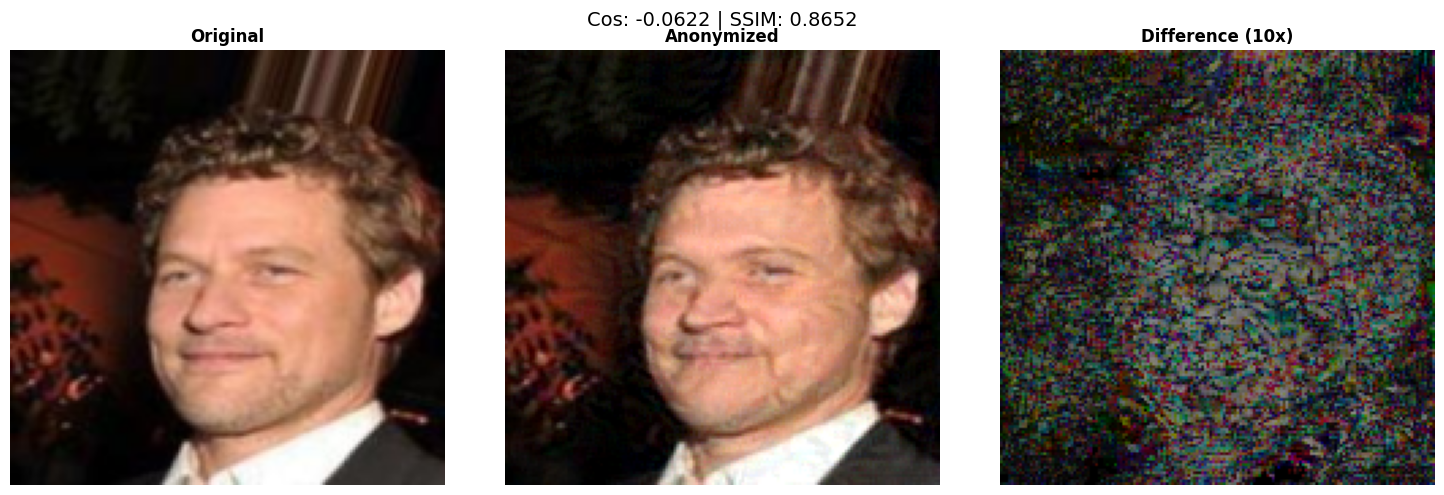

In [ ]:
# Cell 6: Show a few results

test_img, _ = next(iter(train_loader))
A, P, _ = anonymize_multi(test_img, surrogate_models, lpips_fn, verbose=False)

with torch.no_grad():
    cos_vals = {}
    for name, model in test_models.items():
        cos_vals[name] = cosine_similarity(model(test_img), model(A)).item()
    ssim_val = compute_ssim(test_img, A)

print("Sample image results:")
for name, cos in cos_vals.items():
    status = '✅' if cos < 0.0 else ('⚠️' if cos < 0.3 else '❌')
    print(f"  {status} {name}: cos = {cos:.4f}")
print(f"  📊 SSIM: {ssim_val:.4f}")

show_images(test_img, A, cos_val=cos_vals.get('ArcFace', 0), ssim_val=ssim_val)